In [ ]:
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
#from osgeo import gdal, osr, gdalconst, gdal_array
# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に“_B.csv”を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"
    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)
    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)
    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    #‘CenterWavelengthNanometer’, ‘FullWidthAtHalfMaximumNanometer’,
    #‘SolarIrradianceWatt/Meter2/Micron’, ‘ReflectanceMulti’, ‘ReflectanceAdd’
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    for record in record_list:  # 全レコードをループ
        if(record[0]=="RadianceMultiVNIR                                                      "):
            radiancemultivnir = float(record[1])
        if(record[0]=="RadianceAddVNIR                                                        "):
            radianceaddvnir = float(record[1])
        if(record[0]=="RadianceMultiSWIR                                                      "):
            radiancemultiswir = float(record[1])
        if(record[0]=="RadianceAddSWIR                                                        "):
            radianceaddswir = float(record[1])
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成
    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）
    # change to float
    img = 1.0 * img  # 入力画像を浮動小数点数型に変換
    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultivnir + radaddvnir  # 各バンドの値にradmultivnirを掛けてradaddvnirを加える
    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultiswir + radaddswir  # 各バンドの値にradmultiswirを掛けてradaddswirを加える
    img[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定
    return img

# ピクセル空間から地理空間への変換
def show_xy(src, x, y):
    width = src.RasterXSize # srcラスターデータセットの横幅（列数）を取得し格納
    height = src.RasterYSize # srcラスターデータセットの縦幅（行数）を取得し格納
    gt = src.GetGeoTransform() # srcラスターデータセットのジオトランスフォーム（地理変換情報）を取得し、gtに格納
    # gtは6つの要素を持つタプルで、地理座標への変換情報を含む
    # gt[0]: 左上隅のX座標（地理座標系の原点のX座標）。
    # gt[1]: 水平方向のピクセル解像度（ピクセルサイズ、X方向のスケール）。
    # gt[2]: 水平方向の回転（通常は0）。
    # gt[3]: 左上隅のY座標（地理座標系の原点のY座標）。
    # gt[4]: 垂直方向の回転（通常は0）。
    # gt[5]: 垂直方向のピクセル解像度（ピクセルサイズ、Y方向のスケール。通常は負の値、地図の上が北である場合）。
    minx = gt[0]
    miny = gt[3] + width * gt[4] + height * gt[5]
    maxx = gt[0] + width * gt[1] + height * gt[2]
    maxy = gt[3]
    X = gt[0] + x * gt[1] + y * gt[2]
    Y = gt[3] + x * gt[4] + y * gt[5]
    return X, Y

# 地理空間から緯度経度(WGS84)に変換
#def show_latlon(src, x, y):
    old_cs= osr.SpatialReference() # 元の座標系を入れるオブジェクト
    old_cs.ImportFromWkt(src.GetProjectionRef()) # データセットから取得した投影情報（WKT形式）
    # WGS84座標系のWKT（Well-Known Text）表現を文字列として定義
    wgs84_wkt = """
        GEOGCS["WGS 84",
            DATUM["WGS_1984",
                SPHEROID["WGS 84",6378137,298.257223563,
                    AUTHORITY["EPSG","7030"]],
                AUTHORITY["EPSG","6326"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.01745329251994328,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4326"]]"""
    new_cs = osr.SpatialReference() # 新しい座標系を入れるオブジェクト
    new_cs .ImportFromWkt(wgs84_wkt) # 定義したWGS84のWKT文字列をインポート
    # old_csからnew_csへの座標変換を行うためのosr.CoordinateTransformationオブジェクトを作成し、transformに格納
    transform = osr.CoordinateTransformation(old_cs,new_cs)
    X, Y = show_xy(src, x, y) #ピクセル空間から地理空間への変換
    # 計算した地理座標XとYを、transformを使ってWGS84座標系（緯度経度）に変換、格納します
    latlong = transform.TransformPoint(X, Y)
    return latlong

# ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
def get_rgb(img, b=3, g=14, r=29):
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max = np.max(ims)/3  # 画像配列の最大値を取得
    ims /= max   # 画像を max で割って正規化
    ims = np.clip(ims, 0.0, 1.0)  # 画像配列の値を0から255の範囲にクランプ
    #RGBの強さは小数点の場合0から1, 整数の場合は0から255の範囲にある必要がある。
    return ims
    
def show_img(img):
    fig, ax = plt.subplots()  # fig と ax を定義
    ax.axis("off")
    im = ax.imshow(img)  # 画像を表示
    plt.show()

# 指定した座標 (x, y) でのスペクトルデータを表示するための関数
def show_spectral(img, param, y, x): 
    fig, ax = plt.subplots()  # fig と ax を定義
    ax.plot(param[ 0: 58,0], img[y, x,  0: 58], label="VNIR Spectrum", color="r");
    ax.plot(param[58:185,0], img[y, x, 58:185], label="SWIR Spectrum", color="g");
    ax.tick_params(labelsize=16)
    ax.legend();    plt.tight_layout(); plt.show()

#SWIRのデータを抽出
def get_radiance(img, param, y, x):
    wave = param[58:185,0]
    rad = img[y, x, 58:185]
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T

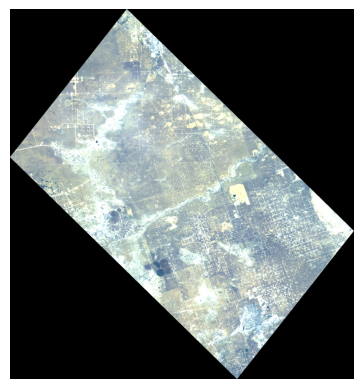

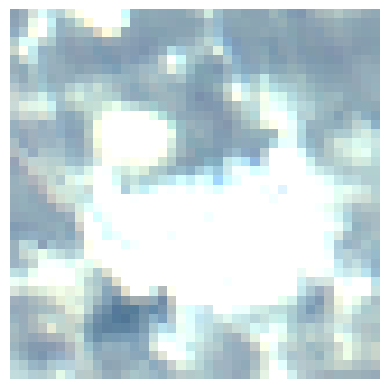

In [ ]:
file = (r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053.tif")
img = tifffile.imread(file) # read tif file
param = read_bfile(file)    # read radiometric file (..._B.csv)
radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(file)  # read meta file (....txt)
img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)  # apply radiometric parameter
ims = get_rgb(img, b=8, g=18, r=28)
center = np.array([1065, 1463]) #中心座標(y, x), ここを変える
#ここで切り取りの範囲を設定
img_slice = img[center[0] - 20 : center[0] + 20, center[1] -20 : center[1] + 20, :] #補正後の画像
ims_slice = ims[center[0] - 20 : center[0] + 20, center[1] -20 : center[1] + 20, :] #画像表示用の画像
show_img(ims)
show_img(ims_slice)

In [ ]:
# 保存名変更水梨シグマも変更
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache
import traceback # エラー詳細表示用
from tqdm import tqdm # 進行度表示ライブラリ

# =========================================================
# HISUI画像処理・読み込み関数群 (変更なし)
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line]
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")
    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str
    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")
    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")
    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    if not all(isinstance(val, (int, float)) for val in [radmultivnir, radmultiswir, radaddvnir, radaddswir]):
       raise TypeError("Radiometric coefficients must be numeric.")
    im = np.ones(img.shape[:2], dtype=np.uint8)
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        im[img[:,:,0] == 0] = 0
    img_float = img.astype(float)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds for image with {img.shape[2]} bands.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float)
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B
    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9:
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9:
       ims.fill(1.0)
    else:
       ims.fill(0.0)
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}, expected at least (185, 1).")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
       raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    if img.shape[2] < 185:
       raise ValueError(f"Image has only {img.shape[2]} bands, expected at least 185 for SWIR extraction.")
    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    if len(wave) != len(rad):
        raise ValueError(f"Wavelength ({len(wave)}) and Radiance ({len(rad)}) length mismatch for SWIR bands.")
    return np.column_stack((wave, rad))

# =========================================================
# CH4 (メタン) 推定関数群 (ご提示いただいた定数を反映)
# =========================================================
hi_i = 58
hi_f = 65
mo_i = 1200
mo_f = 1400

def extract_ch4(data):
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    # *** 注意: ここのCH4レベルはLUT CSVのヘッダーに依存します ***
    # CSVのヘッダーが 0, 0.25, 0.5... の場合
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定
    # もしCSVヘッダーが異なる場合 (例: 0, 0.1, 0.2...)、上記を修正

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)
    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()
    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()


def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths): return []
    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        w_est_np = np.asarray(w_est)
        if w_est_np.shape != observed_rad.shape:
           return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)

def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    if max_ref <= 0: return 0.0, 0.0
    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8) # c=1.8 で初期化
        modtran_wavelengths_ch4_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)
        if not out_adjusted: return 0.0, 0.0
        if rel_max_index >= len(out_adjusted):
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]
        if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0
        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# H2O (水蒸気) 推定関数群 (*** 削除 ***)
# =========================================================
# (このセクションの関数はすべて不要になりました)

# =========================================================
# 共通関数 (変更なし)
# =========================================================
def instrumental_function(data, sigma, mu):
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    sigma = max(sigma, 1e-6)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# LUT 選択・読み込みユーティリティ関数 (*** 削除 ***)
# =========================================================
# (H2O_VALUES, H2O_FILES, list_available_h2o_values, 
#  idx_for_h2o, idx_for_h2o_sticky は不要になりました)

# =========================================================
# LUT 読み込み関数 (CH4用 - 変更なし)
# =========================================================
@lru_cache(maxsize=64) # 念のためキャッシュを維持
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales (Revised)."""
    try:
        df = pd.read_csv(filepath, header=0)
        try:
            data_ch4_raw = df.to_numpy(dtype=object)
            wavelengths = data_ch4_raw[:, 0].astype(float)
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
           raise ValueError(f"Error converting data in {filepath} to float. Check CSV format. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        data_ch4 = data_ch4_raw.T
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
                raise TypeError(f"Cannot apply scaling: Data type non numeric ({data_ch4.dtype}) in {filepath}.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
           raise ValueError(f"Processed LUT {filepath} unexpected shape {data_ch4.shape}.")
        wavelength_row = data_ch4[0, :]
        if np.any(np.isnan(wavelength_row)) or np.any(wavelength_row < 0):
           raise ValueError(f"Wavelength row in {filepath} contains NaN or negative.")
        return data_ch4
    except pd.errors.EmptyDataError: raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError: raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        raise # エラーは再発生させる

# =========================================================
# Main Pixel-by-Pixel Estimation Function (*** ★★★ここを変更★★★ ***)
# =========================================================
def estimate_ch4_only_per_pixel(
    img_slice: np.ndarray,
    param,
    data_ch4_loaded: np.ndarray, # «-- 変更: H2O LUTの代わりに、読み込み済みのCH4 LUTを受け取る
    ch4_init_ppm: float = 1.8,
):
    """ Estimates CH4 pixel by pixel using a two-step (sigma, then CH4) process. """
    if img_slice.ndim != 3: raise ValueError("img_slice must be 3D")
    H, W, C = img_slice.shape
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float) # CH4結果格納用 (sigma, mu, ch4, residual)

    start_time = time.time()
    
    print(f"Starting pixel processing for {H}x{W} image...")
    
    for y in tqdm(range(H), desc=f"Processing {H} rows"):
        for x in range(W):
            try:
                # ---- Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
                if np.max(df_hisui["Radiance"]) <= 0:
                    out_ch4[y, x, :] = 0.0 # 暗黒ピクセルは0を代入
                    continue

                # ---- H2O & LUT Select (*** 削除済 ***) ----

                # =====================================================
                # ---- ★★★ CH4 (Two-Step Estimation) ★★★ ----
                # =====================================================

                # --- Step 1: Estimate Sigma ---
                
                # 1.1. Get initial parameters for a, b (reflectance)
                b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4_loaded, df_hisui)
                
                # 1.2. Set initial guess array for Step 1 (sigma = 6.0)
                a0_ch4_step1 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                
                # 1.3. Run least squares for Step 1
                res_ch4_step1 = least_squares(residuals_ch4, a0_ch4_step1, args=(data_ch4_loaded, df_hisui), method="lm")
                
                # 1.4. Get the estimated sigma from Step 1
                estimated_sigma = float(res_ch4_step1.x[0])
                # (任意: シグマが非現実的な値にならないようクリッピング)
                # estimated_sigma = max(0.1, min(15.0, estimated_sigma)) 

                # --- Step 2: Estimate Methane using new Sigma ---
                
                # 2.1. Set initial guess array for Step 2
                #      ★ estimated_sigma を初期値に使用 ★
                #      その他 (mu, a, b, c, k) は元の初期値に戻す
                a0_ch4_step2 = np.array([estimated_sigma, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])

                # 2.2. Run least squares for Step 2 (This is the final result)
                res_ch4_final = least_squares(residuals_ch4, a0_ch4_step2, args=(data_ch4_loaded, df_hisui), method="lm")

                # --- Store Final Results (from Step 2) ---
                
                out_ch4[y, x, 0] = float(res_ch4_final.x[0])  # final sigma
                out_ch4[y, x, 1] = float(res_ch4_final.x[1])  # final mu
                
                # Clipping for CH4 (ppm)
                ch4_ppm_est = float(res_ch4_final.x[4])
                ch4_ppm_est = max(0, ch4_ppm_est)     # 0未満を0に
                ch4_ppm_est = min(20, ch4_ppm_est)     # 20を超える値を20に
                
                out_ch4[y, x, 2] = ch4_ppm_est # final ch4 (ppm)
                
                # Calculate final residual
                residual_values = residuals_ch4(res_ch4_final.x, data_ch4_loaded, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2))
                # =====================================================
                # ---- ★★★ 変更ここまで ★★★ ----
                # =====================================================

            except Exception as e_pix:
                # print(f"Error at pixel ({y},{x}): {e_pix}") # Debugging
                pass

    end_time = time.time()
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {H*W}")
    print(f"NaN count CH4: {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total time: {end_time - start_time:.2f} seconds.")
    return out_ch4

# =========================================================
# Example Usage (ご提示いただいたパスと定数を反映)
# =========================================================
try:
    # --- ★★★ 手動でCH4 LUTファイルを指定 ★★★ ---
    MANUAL_CH4_LUT_FILE = r"E:\メタン\pb\HSHL1G_N313W1018_20210409165443_20231225234124\waterluts\1.1.csv" # «-- ご提示のパス
    # ----------------------------------------------------

    # --- ★指定されたCH4 LUTを1回だけ読み込む ---
    print(f"Loading manual CH4 LUT: '{MANUAL_CH4_LUT_FILE}'")
    data_ch4_loaded_np = load_ch4_lut(MANUAL_CH4_LUT_FILE)
    print(f"CH4 LUT loaded. Shape: {data_ch4_loaded_np.shape}")


    # --- HISUI画像データ (img_slice) とパラメータ (param) の準備 ---
    # (ここは元のコードと同様に、img_slice と param が定義されている前提)
    
    # (ダミーデータのセクションは参考までに残しておきます)
    # === ダミーデータの例 (この部分は実際のものに置き換えてください) ===
    # if 'img_slice' not in locals():
    #     print("Warning: 'img_slice' not defined. Using 10x10 dummy data.")
    #     img_slice = np.random.randint(1000, 2000, size=(10, 10, 185)).astype(float)
    #     img_slice[:, :, 10] = 1500 # ゼロでないデータ
    # if 'param' not in locals():
    #     print("Warning: 'param' not defined. Using dummy data.")
    #     param = np.zeros((185, 5))
    #     param[:, 0] = np.linspace(400, 2500, 185) # ダミーの波長
    # === ダミーデータの例ここまで ===


    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # --- 推定実行 (変更なし) ---
        out_ch4 = estimate_ch4_only_per_pixel(
            img_slice, param, data_ch4_loaded_np,
            ch4_init_ppm=1.8
        )

        # --- 結果表示 & 保存 (H2O部分を削除) ---
        print("\n--- Results ---")
        sample_step = max(1, img_slice.shape[0] // 5) 
        print("\nCH4 ppm (sample):\n", out_ch4[::sample_step, ::sample_step, 2])
        
        # «-- ★★★ 変更: ファイル名を hi_i と hi_f を使って動的に生成 ★★★
        csv_filename = f"estimated_ch4_ppm_{hi_i}_{hi_f}.csv"
        png_filename = f"estimated_ch4_map_{hi_i}_{hi_f}.png"
        # «-- ★★★ 変更ここまで ★★★
        
        h, w, _ = out_ch4.shape
        ch4_ppm_2d = out_ch4[:, :, 2]
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d)
        df_ch4_ppm.to_csv(csv_filename, index=False, header=False, na_rep='NaN') # «-- 変更
        print(f"\nCH4 PPM results saved to '{csv_filename}'.") # «-- 変更

        # --- マップ表示 (変更なし) ---
        try:
            ch4_ppm_map = out_ch4[:, :, 2]
            ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0に
            interp = 'nearest' if max(ch4_ppm_map_filled.shape) < 100 else 'bilinear'
            
            fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8))
            im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation=interp)
            cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
            cbar.set_label('Estimated CH4 (ppm)')
            ax_ch4.set_title('Estimated Methane Concentration Map')
            ax_ch4.axis('off')
            plt.savefig(png_filename, bbox_inches='tight') # «-- 変更
            print(f"Map saved to '{png_filename}'.") # «-- 変更
            plt.close(fig_ch4)
        except Exception as e_map:
            print(f"Failed to generate map: {e_map}")

    else:
        print("Error: img_slice or param not defined. (Example Usage section skipped)")

# --- エラー処理 ---
except FileNotFoundError as e: print(f"Error: File not found: {e}.")
except NameError as e: print(f"Error: Variable not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Loading manual CH4 LUT: 'E:\メタン\pb\HSHL1G_N313W1018_20210409165443_20231225234124\waterluts\1.1.csv'
CH4 LUT loaded. Shape: (22, 2121)
img_slice shape: (40, 40, 185)
Starting pixel processing for 40x40 image...


Processing 40 rows:  15%|█▌        | 6/40 [1:56:43<11:01:29, 1167.33s/it]


KeyboardInterrupt: 

In [ ]:
# 保存名変更水梨
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache
import traceback # エラー詳細表示用
from tqdm import tqdm # 進行度表示ライブラリ

# =========================================================
# HISUI画像処理・読み込み関数群 (変更なし)
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line]
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")
    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str
    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")
    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")
    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    if not all(isinstance(val, (int, float)) for val in [radmultivnir, radmultiswir, radaddvnir, radaddswir]):
       raise TypeError("Radiometric coefficients must be numeric.")
    im = np.ones(img.shape[:2], dtype=np.uint8)
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        im[img[:,:,0] == 0] = 0
    img_float = img.astype(float)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds for image with {img.shape[2]} bands.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float)
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B
    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9:
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9:
       ims.fill(1.0)
    else:
       ims.fill(0.0)
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}, expected at least (185, 1).")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
       raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    if img.shape[2] < 185:
       raise ValueError(f"Image has only {img.shape[2]} bands, expected at least 185 for SWIR extraction.")
    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    if len(wave) != len(rad):
        raise ValueError(f"Wavelength ({len(wave)}) and Radiance ({len(rad)}) length mismatch for SWIR bands.")
    return np.column_stack((wave, rad))

# =========================================================
# CH4 (メタン) 推定関数群 (hi_i, hi_f など変更済み)
# =========================================================
hi_i = 58
hi_f = 65
mo_i = 1800
mo_f = 2100

def extract_ch4(data):
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    # *** 注意: ここのCH4レベルはLUT CSVのヘッダーに依存します ***
    # CSVのヘッダーが 0, 0.25, 0.5... の場合
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定
    # もしCSVヘッダーが異なる場合 (例: 0, 0.1, 0.2...)、上記を修正

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)
    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()
    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()


def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths): return []
    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        w_est_np = np.asarray(w_est)
        if w_est_np.shape != observed_rad.shape:
           return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)

def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    if max_ref <= 0: return 0.0, 0.0
    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8) # c=1.8 で初期化
        modtran_wavelengths_ch4_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)
        if not out_adjusted: return 0.0, 0.0
        if rel_max_index >= len(out_adjusted):
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]
        if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0
        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# H2O (水蒸気) 推定関数群 (*** 削除 ***)
# =========================================================
# (このセクションの関数はすべて不要になりました)

# =========================================================
# 共通関数 (変更なし)
# =========================================================
def instrumental_function(data, sigma, mu):
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    sigma = max(sigma, 1e-6)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# LUT 選択・読み込みユーティリティ関数 (*** 削除 ***)
# =========================================================
# (H2O_VALUES, H2O_FILES, list_available_h2o_values, 
#  idx_for_h2o, idx_for_h2o_sticky は不要になりました)

# =========================================================
# LUT 読み込み関数 (CH4用 - 変更なし)
# =========================================================
@lru_cache(maxsize=64) # 念のためキャッシュを維持
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales (Revised)."""
    try:
        df = pd.read_csv(filepath, header=0)
        try:
            data_ch4_raw = df.to_numpy(dtype=object)
            wavelengths = data_ch4_raw[:, 0].astype(float)
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
           raise ValueError(f"Error converting data in {filepath} to float. Check CSV format. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        data_ch4 = data_ch4_raw.T
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
                raise TypeError(f"Cannot apply scaling: Data type non numeric ({data_ch4.dtype}) in {filepath}.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
           raise ValueError(f"Processed LUT {filepath} unexpected shape {data_ch4.shape}.")
        wavelength_row = data_ch4[0, :]
        if np.any(np.isnan(wavelength_row)) or np.any(wavelength_row < 0):
           raise ValueError(f"Wavelength row in {filepath} contains NaN or negative.")
        return data_ch4
    except pd.errors.EmptyDataError: raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError: raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        raise # エラーは再発生させる

# =========================================================
# Main Pixel-by-Pixel Estimation Function (*** ★★★ここを変更★★★ ***)
# =========================================================
def estimate_ch4_only_per_pixel(
    img_slice: np.ndarray,
    param,
    data_ch4_loaded: np.ndarray, # «-- 変更: H2O LUTの代わりに、読み込み済みのCH4 LUTを受け取る
    ch4_init_ppm: float = 1.8,
):
    """ Estimates CH4 pixel by pixel using a two-step (sigma, then CH4) process. """
    if img_slice.ndim != 3: raise ValueError("img_slice must be 3D")
    H, W, C = img_slice.shape
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float) # CH4結果格納用 (sigma, mu, ch4, residual)

    start_time = time.time()
    
    print(f"Starting pixel processing for {H}x{W} image...")
    
    for y in tqdm(range(H), desc=f"Processing {H} rows"):
        for x in range(W):
            try:
                # ---- Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
                if np.max(df_hisui["Radiance"]) <= 0:
                    out_ch4[y, x, :] = 0.0 # 暗黒ピクセルは0を代入
                    continue

                # =====================================================
                # ---- ★★★ CH4 (Two-Step Estimation with Fix) ★★★ ----
                # =====================================================

                # --- Step 1: Estimate Sigma (Free parameters) ---
                
                # 1.1. Get initial parameters for a, b (reflectance)
                b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4_loaded, df_hisui)
                
                # 1.2. Set initial guess array for Step 1 (sigma = 6.0)
                a0_ch4_step1 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                
                # 1.3. Run least squares for Step 1
                res_ch4_step1 = least_squares(residuals_ch4, a0_ch4_step1, args=(data_ch4_loaded, df_hisui), method="lm")
                
                # 1.4. Get the estimated sigma from Step 1
                estimated_sigma = float(res_ch4_step1.x[0])
                # (任意: シグマが非現実的な値にならないようクリッピング)
                estimated_sigma = max(0.1, min(15.0, estimated_sigma)) # Sigmaは正である必要あり

                # --- Step 2: Estimate Methane with FIXED Sigma ---
                
                # 2.1. Set initial guess array for Step 2
                #      (sigma以外は元の初期値に戻す)
                a0_ch4_step2 = np.array([estimated_sigma, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])

                # 2.2. ★★★ DEFINE BOUNDS ★★★
                # パラメータ: [sigma, mu, a, b, c(ch4), k]
                # bounds_lb (下限): sigmaを固定, c(ch4)は0.0以上
                bounds_lb = np.array([estimated_sigma, -np.inf, -np.inf, -np.inf, 0.0, -np.inf])
                # bounds_ub (上限): sigmaを固定, c(ch4)は20.0以下
                bounds_ub = np.array([estimated_sigma,  np.inf,  np.inf,  np.inf, 20.0, np.inf])
                # ★ lb[0] == ub[0] とすることで、sigma (0番目のパラメータ) が固定されます
                
                # 2.3. Run least squares for Step 2 (with bounds)
                res_ch4_final = least_squares(
                    residuals_ch4, 
                    a0_ch4_step2, 
                    args=(data_ch4_loaded, df_hisui), 
                    method="lm", 
                    bounds=(bounds_lb, bounds_ub) # ★ Boundsを適用
                )

                # --- Store Final Results (from Step 2) ---
                
                out_ch4[y, x, 0] = float(res_ch4_final.x[0])  # final sigma (固定された値)
                out_ch4[y, x, 1] = float(res_ch4_final.x[1])  # final mu
                
                # boundsで 0-20ppm が保証されている
                ch4_ppm_est = float(res_ch4_final.x[4])
                out_ch4[y, x, 2] = ch4_ppm_est # final ch4 (ppm)
                
                # Calculate final residual
                residual_values = residuals_ch4(res_ch4_final.x, data_ch4_loaded, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2))
                # =====================================================
                # ---- ★★★ 変更ここまで ★★★ ----
                # =====================================================

            except Exception as e_pix:
                # print(f"Error at pixel ({y},{x}): {e_pix}") # Debugging
                pass

    end_time = time.time()
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {H*W}")
    print(f"NaN count CH4: {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total time: {end_time - start_time:.2f} seconds.")
    return out_ch4

# =========================================================
# Example Usage (メインの実行部分 - 変更なし)
# =========================================================
try:
    # --- ★★★ 手動でCH4 LUTファイルを指定 ★★★ ---
    MANUAL_CH4_LUT_FILE = r"E:\メタン\pb\HSHL1G_N313W1018_20210409165443_20231225234124\waterluts\1.1.csv" # «-- ご提示のパス
    # ----------------------------------------------------

    # --- ★指定されたCH4 LUTを1回だけ読み込む ---
    print(f"Loading manual CH4 LUT: '{MANUAL_CH4_LUT_FILE}'")
    data_ch4_loaded_np = load_ch4_lut(MANUAL_CH4_LUT_FILE)
    print(f"CH4 LUT loaded. Shape: {data_ch4_loaded_np.shape}")


    # --- HISUI画像データ (img_slice) とパラメータ (param) の準備 ---
    # (ここは元のコードと同様に、img_slice と param が定義されている前提)
    
    # (ダミーデータのセクションは参考までに残しておきます)
    # === ダミーデータの例 (この部分は実際のものに置き換えてください) ===
    # if 'img_slice' not in locals():
    #     print("Warning: 'img_slice' not defined. Using 10x10 dummy data.")
    #     img_slice = np.random.randint(1000, 2000, size=(10, 10, 185)).astype(float)
    #     img_slice[:, :, 10] = 1500 # ゼロでないデータ
    # if 'param' not in locals():
    #     print("Warning: 'param' not defined. Using dummy data.")
    #     param = np.zeros((185, 5))
    #     param[:, 0] = np.linspace(400, 2500, 185) # ダミーの波長
    # === ダミーデータの例ここまで ===


    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # --- 推定実行 (変更なし) ---
        out_ch4 = estimate_ch4_only_per_pixel(
            img_slice, param, data_ch4_loaded_np,
            ch4_init_ppm=1.8
        )

        # --- 結果表示 & 保存 (H2O部分を削除) ---
        print("\n--- Results ---")
        sample_step = max(1, img_slice.shape[0] // 5) 
        print("\nCH4 ppm (sample):\n", out_ch4[::sample_step, ::sample_step, 2])
        
        # «-- ★★★ 変更: ファイル名を hi_i と hi_f を使って動的に生成 ★★★
        csv_filename = f"estimated_ch4_ppm_{hi_i}_{hi_f}.csv"
        png_filename = f"estimated_ch4_map_{hi_i}_{hi_f}.png"
        # «-- ★★★ 変更ここまで ★★★
        
        h, w, _ = out_ch4.shape
        ch4_ppm_2d = out_ch4[:, :, 2]
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d)
        df_ch4_ppm.to_csv(csv_filename, index=False, header=False, na_rep='NaN') # «-- 変更
        print(f"\nCH4 PPM results saved to '{csv_filename}'.") # «-- 変更

        # --- マップ表示 (変更なし) ---
        try:
            ch4_ppm_map = out_ch4[:, :, 2]
            ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0に
            interp = 'nearest' if max(ch4_ppm_map_filled.shape) < 100 else 'bilinear'
            
            fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8))
            im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation=interp)
            cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
            cbar.set_label('Estimated CH4 (ppm)')
            ax_ch4.set_title('Estimated Methane Concentration Map')
            ax_ch4.axis('off')
            plt.savefig(png_filename, bbox_inches='tight') # «-- 変更
            print(f"Map saved to '{png_filename}'.") # «-- 変更
            plt.close(fig_ch4)
        except Exception as e_map:
            print(f"Failed to generate map: {e_map}")

    else:
        print("Error: img_slice or param not defined. (Example Usage section skipped)")

# --- エラー処理 ---
except FileNotFoundError as e: print(f"Error: File not found: {e}.")
except NameError as e: print(f"Error: Variable not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()